 # Gesture‑Based Control Systems

In [26]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [27]:
data_dir = "images"   
img_size = 64         

X = []
y = []

print("📂 Loading dataset from:", data_dir)

for idx, folder in enumerate(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder)
    if not os.path.isdir(folder_path):
        continue  

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        try:
            img = cv2.imread(img_path)
            if img is None:
                print("   ⚠️ Skipping (not an image):", img_path)
                continue
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(idx)
        except Exception as e:
            print("   ❌ Error reading:", img_path, "Error:", e)

print("✅ Finished loading images")
print("Total samples:", len(X))

📂 Loading dataset from: images
✅ Finished loading images
Total samples: 3300


In [28]:
X = np.array(X, dtype="float32") / 255.0   
y = to_categorical(np.array(y))            

print("✅ Dataset prepared")
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Train-test split done")

✅ Dataset prepared
X shape: (3300, 64, 64, 3)
y shape: (3300, 12)
✅ Train-test split done


In [29]:
print("🛠️ Building CNN model...")
num_classes = y.shape[1]

model = Sequential([
    Input(shape=(img_size, img_size, 3)),          
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')        
])

print("✅ Model built successfully")
model.summary()   

🛠️ Building CNN model...
✅ Model built successfully


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,700 (6.21 MB)

 Trainable params: 1,626,700 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
print("⚙️ Compiling model...")
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=10,
                    batch_size=32,
                    verbose=1)
print("✅ Training complete")

⚙️ Compiling model...
Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.4254 - loss: 1.7335 - val_accuracy: 0.8803 - val_loss: 0.6570
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8515 - loss: 0.5103 - val_accuracy: 0.9803 - val_loss: 0.1392
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9375 - loss: 0.2159 - val_accuracy: 0.9894 - val_loss: 0.0590
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9708 - loss: 0.1037 - val_accuracy: 0.9955 - val_loss: 0.0234
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9811 - loss: 0.0721 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9879 - loss: 0.0486 - val_accuracy: 0.9985 - val_loss: 0.0149
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.9917 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9920 - loss: 0.0308 - v

In [31]:
print("📊 Evaluating model...")
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.2f}")

📊 Evaluating model...
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 5.2732e-04
Test Loss: 0.0005
Test Accuracy: 1.00


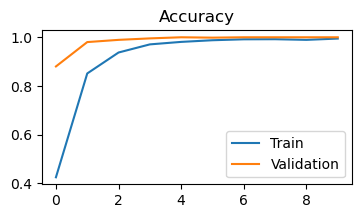

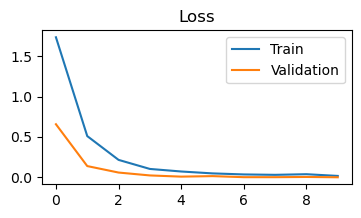

In [34]:
import matplotlib.pyplot as plt

# Smaller figure size
plt.figure(figsize=(4,2))   # width=5, height=3 inches
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(4,2))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()
